In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation
import numpy as np

from torchvision.io import read_image
from pathlib import Path
import torchvision.transforms.functional as F
from skimage.io import imread

from torchvision.models.segmentation import fcn_resnet50
from torchvision.transforms.functional import gaussian_blur
from torchvision.transforms.functional import convert_image_dtype
import torch
from torchvision.utils import draw_segmentation_masks

from torchvision.transforms import GaussianBlur
import numpy as np
import pywt
from skimage.measure import shannon_entropy, blur_effect
import cv2
import imagecodecs

In [2]:
plt.rcParams["savefig.bbox"] = 'tight'


def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

tensor(1, dtype=torch.uint8) tensor(255, dtype=torch.uint8)


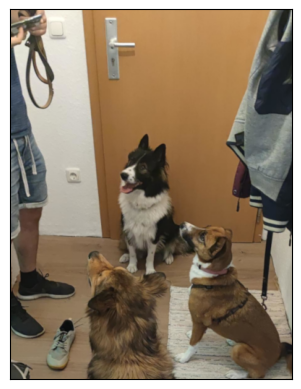

In [3]:
img = read_image(
    str(Path('/mnt/extraStorage/example_images_for_coco') / 'testcoco.png'))[:3, :, :]

show(img)
print(img.min(), img.max())

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = fcn_resnet50(pretrained=True, progress=False).to(device)
model = model.eval()
for param in model.parameters():
    param.requires_grad_(False)

img = convert_image_dtype(img, dtype=torch.float).to(device)
normalized_img = F.normalize(img, mean=(
    0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
output = model(normalized_img.unsqueeze(0))['out']
print(output.shape, output.min().item(), output.max().item())
normalized_masks = torch.nn.functional.softmax(output, dim=1)

Using device: cuda


/home/amikliss/miniforge3/envs/segStrategiesEnv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/amikliss/miniforge3/envs/segStrategiesEnv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([1, 21, 512, 390]) -6.6516828536987305 14.477781295776367


dog1_masks shape = torch.Size([21, 512, 390]), dtype = torch.float32
dog1_all_classes_masks = torch.Size([21, 512, 390]), dtype = torch.bool


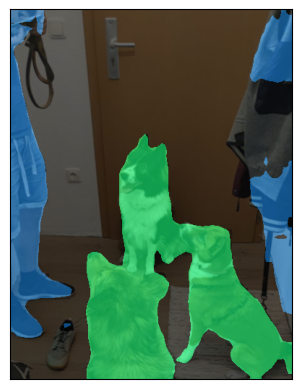

torch.Size([512, 390])


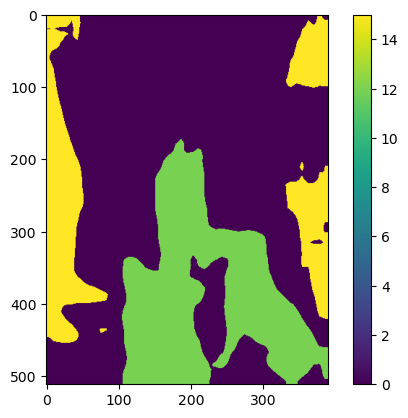

In [9]:
num_classes = normalized_masks.shape[1]
dog1_masks = normalized_masks[0]
class_dim = 0
dog1_all_classes_masks = dog1_masks.cpu().argmax(
    class_dim) == torch.arange(num_classes)[:, None, None]

print(f"dog1_masks shape = {dog1_masks.shape}, dtype = {dog1_masks.dtype}")
print(
    f"dog1_all_classes_masks = {dog1_all_classes_masks.shape}, dtype = {dog1_all_classes_masks.dtype}")

dog_with_all_masks = draw_segmentation_masks(
    img, masks=dog1_all_classes_masks, alpha=.6)
show(dog_with_all_masks)
plt.show()

print(dog1_masks.argmax(0).shape)
plt.imshow(dog1_masks.cpu().argmax(0))
plt.colorbar()
plt.show()

In [32]:
def get_output_for_image(image, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), use_grad=False):
    assert image.shape[0] == 3, "Image should have 3 channels"
    image = convert_image_dtype(image, dtype=torch.float)
    normalized_image = F.normalize(image, mean=mean, std=std)

    if use_grad:
        output = model(normalized_image.unsqueeze(0))['out']
    else:
        with torch.no_grad():
            output = model(normalized_image.unsqueeze(0))['out']

    output = torch.nn.functional.softmax(output, dim=1)
    return output[0]


def tv_loss(img):
    """Compute the total variation loss of an image."""
    dx = img[:, :, 1:, :] - img[:, :, :-1, :]
    dy = img[:, :, :, 1:] - img[:, :, :, :-1]
    return (dx.pow(2).mean() + dy.pow(2).mean())


def compress_jpg2k(image, quality):
    """Compress an image using JPEG 2000 with the specified quality."""
    arr = image.permute(1, 2, 0).contiguous().cpu()
    if torch.is_floating_point(arr):
        lo, hi = arr.min(), arr.max()
        arr = (arr.clamp(lo, hi) - lo) / max(1e-12, (hi - lo))
        arr = (arr * 255.0).round().clamp(0, 255).to(torch.uint8)
    else:
        arr = arr.to(torch.uint8)

    jp2_bytes = imagecodecs.jpeg2k_encode(arr, level=quality, reversible=True)
    decode = torch.tensor(imagecodecs.jpeg2k_decode(
        jp2_bytes), device=image.device)

    if torch.is_floating_point(image):
        decode = decode.to(torch.float32) / 255.0 * (hi - lo) + lo

    return decode.permute(2, 0, 1)

In [69]:
def calculate_dice_loss(x_output, reference_output):
    """
    Calculate the total loss for the repairing step, which includes the Dice loss, total variation loss, and the alpha term.

    """
    # calculate Dice loss
    intersection = 2.0 * (x_output * reference_output).sum(dim=(1, 2))
    denom = (x_output.pow(2) + reference_output.pow(2)).sum(dim=(1, 2))
    dice = (intersection + 1e-6) / (denom + 1e-6)
    dice_loss = 1.0 - dice[1:].mean()
    return dice_loss


def calculate_loss(x, alpha, x_output, reference_output, lambda_tv, lambda_alpha, dice_weight=0.1):
    """
            Calculate the total loss for the repairing step, which includes the Dice loss, total variation loss, and the alpha term.

            """
    # calculate Dice loss
    dice_loss = calculate_dice_loss(x_output, reference_output)

    loss_alpha = lambda_alpha * alpha.mean()
    loss_tv = lambda_tv * tv_loss(alpha.unsqueeze(0).unsqueeze(0))

    loss_simplification = - loss_alpha
    loss_simplification += loss_tv

    loss = dice_weight * dice_loss + loss_simplification

    return loss, dice_loss, loss_simplification, -loss_alpha, loss_tv

In [115]:
def show_result_of_repairing(original_input, original_seg, simp_input, simp_segmentation, rep_input, rep_segmentation, alpha_mask, metrics, iteration):

    log_dice, log_alpha_mean, log_tv, log_loss = metrics

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle(f"Iteration {iteration}")

    axes[0, 0].imshow(np.moveaxis(original_input.cpu().numpy(), 0, -1))
    axes[0, 0].set_title("original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(np.moveaxis(simp_input.cpu().detach().numpy(), 0, -1))
    axes[0, 1].set_title("simplified")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(np.moveaxis(
        rep_input.squeeze().cpu().detach().numpy(), 0, -1))
    axes[0, 2].set_title("repaired")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(original_seg.argmax(0).cpu().numpy())
    axes[1, 0].set_title("original_seg")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(simp_segmentation.argmax(0).cpu().detach().numpy())
    axes[1, 1].set_title("simp_segmentation")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(rep_segmentation.squeeze().argmax(
        0).cpu().detach().numpy())
    axes[1, 2].set_title("rep_segmentation")
    axes[1, 2].axis("off")

    alpha_plt = axes[2, 0].imshow(alpha_mask.cpu().numpy())
    fig.colorbar(alpha_plt, ax=axes[2, 0])
    axes[2, 0].set_title("alpha_mask")
    axes[2, 0].axis("off")

    plt.show()

    plt.plot(log_dice)
    plt.plot(log_alpha_mean)
    plt.plot(log_tv)
    plt.plot(log_loss)
    # if reduced_at_iteration:
    #     plt.plot([reduced_at_iteration],
    #              log_loss[reduced_at_iteration], 'rx', label='LR reduced')
    plt.legend(["dice loss", "mean_alpha", "tv_loss",

                "total loss"])
    plt.show()

torch.float32


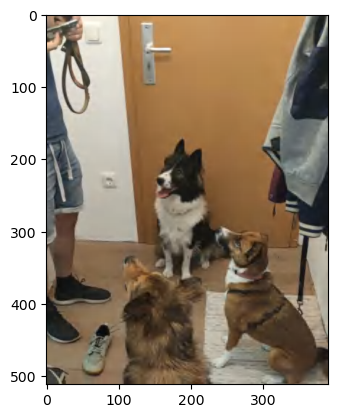

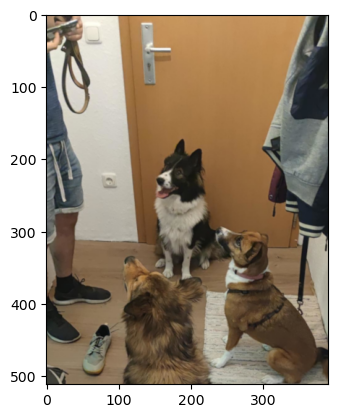

In [178]:
test_image = img.clone()
print(test_image.dtype)

comp = compress_jpg2k(test_image, quality=35)
plt.imshow(comp.permute(1, 2, 0).cpu().numpy())
plt.show()
plt.imshow(img.permute(1, 2, 0).cpu().numpy())

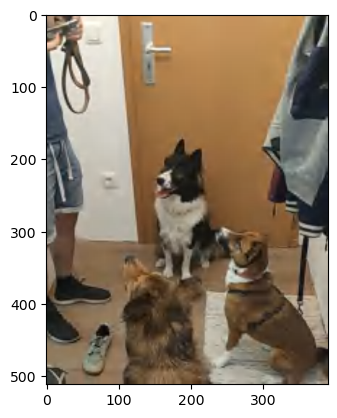

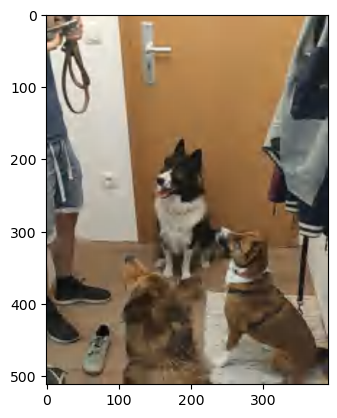

In [180]:
comp2 = compress_jpg2k(comp, 35)
plt.imshow(comp2.permute(1, 2, 0).cpu().numpy())
plt.show()
comp3 = compress_jpg2k(comp2, 35)
plt.imshow(comp3.permute(1, 2, 0).cpu().numpy())
plt.show()

In [181]:
def do_simplification_jpg2k(model, input, max_simp_it=10, max_it_opt=100, dice_er=2e-2, lambda_tv=0.1, lambda_alpha=0.1, patience_simplification=25, mod_show=2, repairing_patience=50):
    """
    Perform simplification of an image using JPEG2000 compression and optimization.

    Parameters:
    - model: The segmentation model to use for computing the segmentation.
    - input: The input image tensor.
    - max_simp_it: Maximum number of simplification iterations.
    - max_it_opt: Maximum number of optimization iterations for repairing step.
    - dice_er: Dice error threshold.
    - lambda_tv: Weight for total variation loss.
    - lambda_alpha: Weight for the alpha penalty.
    - patience_simplification: Number of iterations to wait before stopping simplification.
    - mod_show: Frequency of showing intermediate results.
    - repairing_patience: Number of iterations to wait before stopping repair optimization.

    Returns:
    - simplified_image: The simplified image tensor.
    """
    device = next(model.parameters()).device
    print("device", device)

    input = convert_image_dtype(input, dtype=torch.float).to(device)
    input = input / input.max()

    reference_output = get_output_for_image(input, use_grad=False)
    last_simp_img = input.clone().to(device)

    quality = 35  # inital quality for JPEG2k compression

    all_simp_imgs = []
    all_seg_simp = []
    all_alpha_masks = []
    all_repaired_imgs = []
    all_seg_repaired = []

    for simp_it in range(max_simp_it):

        # compress image with jpg2k
        next_simp_img = compress_jpg2k(
            last_simp_img, quality=quality).to(device)
        all_simp_imgs.append(next_simp_img)
        # reduce quality
        # quality = quality * 0.9

        # prepare alpha parameter for optimization
        alpha_param = torch.full_like(
            next_simp_img[0], 0.0, requires_grad=True, device=device, dtype=torch.float)
        optimizer = torch.optim.Adam([alpha_param], lr=0.01)
        a_stacked = torch.stack([alpha_param] * 3, dim=0).to(device)
        best_alpha = alpha_param.clone().detach()

        best_x = last_simp_img.to(
            device) * (1 - a_stacked) + next_simp_img * a_stacked
        best_simplification_loss = torch.inf

        out_simp = get_output_for_image(next_simp_img, use_grad=False)
        all_seg_simp.append(out_simp)
        best_out = out_simp.clone().detach()

        plt.imshow(out_simp.argmax(0).cpu().numpy())
        plt.show()

        dice_loss = calculate_dice_loss(out_simp, reference_output)
        print(
            f"Initial dice loss for simplification {simp_it}: {dice_loss.item():.4f}")
        best_dice = dice_loss

        dice_weight = 0.01  # adjust weight of dice regarding dice outcome

        log_loss = []
        log_dice = []
        log_simplification = []
        log_alpha_mean = []
        log_tv = []
        no_improvement_repairing = 0

        print("inital dice loss", dice_loss)
        # start repairing procedure
        if dice_loss > dice_er:
            for opt_it in range(max_it_opt):
                print("opt_it", opt_it)
                optimizer.zero_grad()

                alpha = torch.clamp(alpha_param, 0, 1)
                a_stacked = torch.stack([alpha_param] * 3, dim=0).to(device)
                x = last_simp_img * (1 - a_stacked) + next_simp_img * a_stacked
                out_x = get_output_for_image(x, use_grad=True)

                # calculate loss
                loss, dice_loss, loss_simplification, loss_alpha, loss_tv = calculate_loss(
                    x, alpha, out_x, reference_output, lambda_tv, lambda_alpha, dice_weight)

                log_loss.append(loss.item())
                log_simplification.append(loss_simplification.item())
                log_dice.append(dice_loss.item())
                log_alpha_mean.append(- loss_alpha.item())
                log_tv.append(loss_tv.item())

                if (dice_loss < dice_er) and (loss_simplification < best_simplification_loss):
                    best_alpha = alpha.detach().clone()
                    best_simplification_loss = loss_simplification
                    best_x = x.clone().detach()
                    best_out = out_x.clone().detach()
                    best_dice = dice_loss.clone().detach()
                    dice_weight = np.clip(dice_weight - 0.1, 0, 1000)
                    no_improvement_repairing = 0
                    print(f"decrease dice weight to {dice_weight}")
                else:
                    no_improvement_repairing += 1
                    if dice_loss >= dice_er:
                        dice_weight += 0.2
                        print(f"increased dice_weight to {dice_weight}")
                    elif dice_loss >= log_dice[-1]:
                        dice_weight += 0.1
                        print(f"increased dice_weight to {dice_weight}")
                    print("no_improvement_counter", no_improvement_repairing)

                if no_improvement_repairing >= repairing_patience:
                    print(
                        f"No improvement in Dice and loss for {repairing_patience} iterations, stopping.")
                    break

                print("do_backprop")
                loss.backward()
                print("perform op step")
                optimizer.step()
                print("loss", loss.item())

        show_result_of_repairing(input, reference_output, next_simp_img, out_simp,
                                 best_x, best_out, best_alpha, metrics=(log_dice, log_alpha_mean, log_tv, log_loss), iteration=simp_it)

        # for the next simplification iteration
        last_simp_img = best_x.clone().detach()

        # log
        all_alpha_masks.append(best_alpha.cpu())
        all_repaired_imgs.append(last_simp_img.clone())
        all_seg_repaired.append(best_out.clone())

        if (best_dice > dice_er):
            print("Stop because the dice is not good enough")
            break

device cuda:0


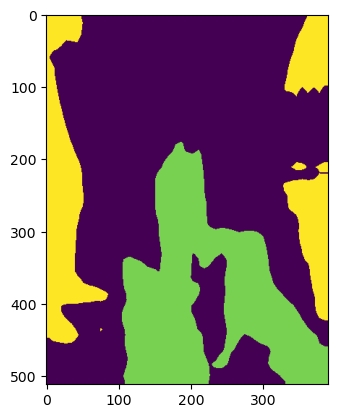

Initial dice loss for simplification 0: 0.4835
inital dice loss tensor(0.4835, device='cuda:0')
opt_it 0
decrease dice weight to 0.0
do_backprop
perform op step
loss 0.0
opt_it 1
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.0009804228320717812
opt_it 2
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.0019608456641435623
opt_it 3
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.0029412689618766308
opt_it 4
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.003921691328287125
opt_it 5
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.00490211509168148
opt_it 6
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.0058825379237532616
opt_it 7
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.006862960755825043
opt_it 8
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.00784338265657425
opt_it 9
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.008823806419968605


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06647846..1.0091712].


loss -0.08656491339206696
opt_it 499
decrease dice weight to 0.10000000000000014
do_backprop
perform op step
loss -0.08719389140605927


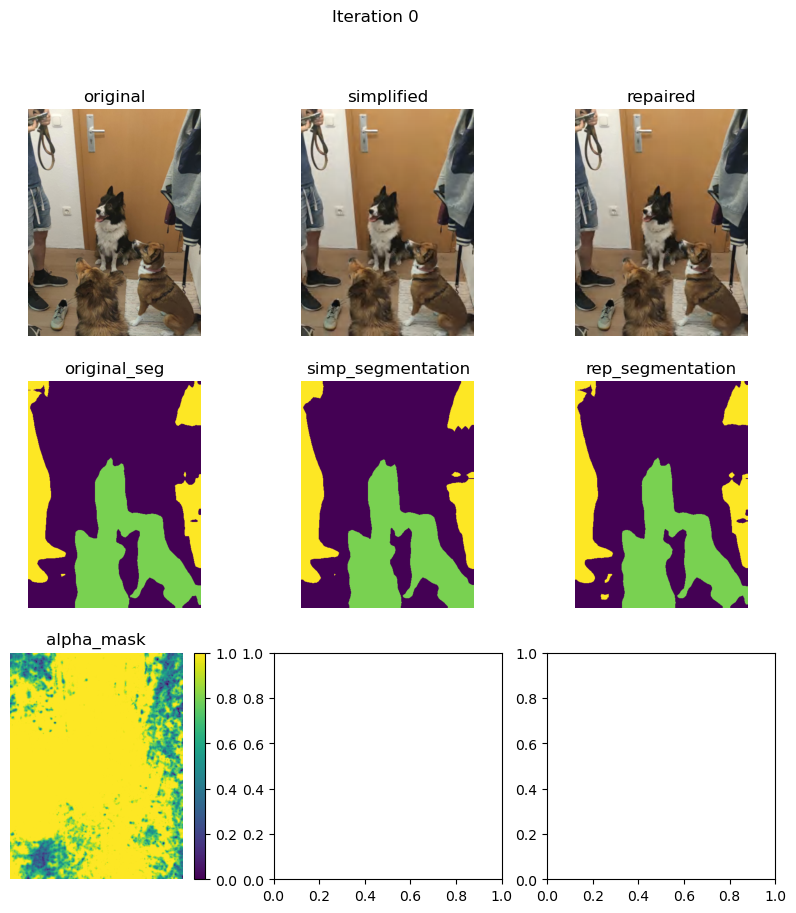

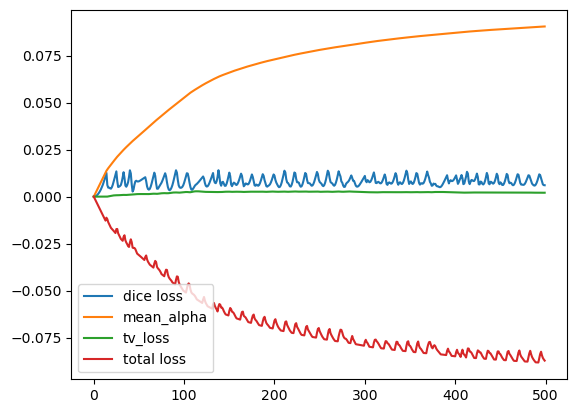

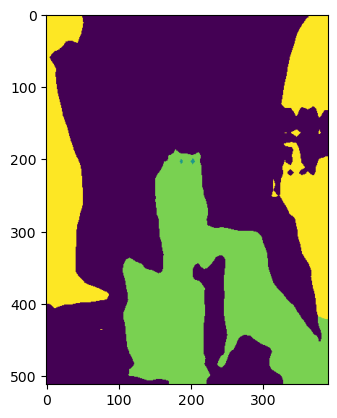

Initial dice loss for simplification 1: 0.5406
inital dice loss tensor(0.5406, device='cuda:0')
opt_it 0
decrease dice weight to 0.0
do_backprop
perform op step
loss 6.066381683922373e-05
opt_it 1
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.0009757556836120784
opt_it 2
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.0019481354393064976
opt_it 3
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.002919314196333289
opt_it 4
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.0038892391603440046
opt_it 5
increased dice_weight to 0.2
no_improvement_counter 1
do_backprop
perform op step
loss -0.004857927095144987
opt_it 6
increased dice_weight to 0.4
no_improvement_counter 2
do_backprop
perform op step
loss -0.0032497451175004244
opt_it 7
decrease dice weight to 0.30000000000000004
do_backprop
perform op step
loss -0.003479273524135351
opt_it 8
decrease dice weight to 0.20000000000000004
do_backprop
perform op step
loss -0.0046455

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06647846..1.0091712].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09674771..1.0621645].


loss -0.07089130580425262
opt_it 499
increased dice_weight to 3.100000000000002
no_improvement_counter 25
do_backprop
perform op step
loss -0.07051447778940201


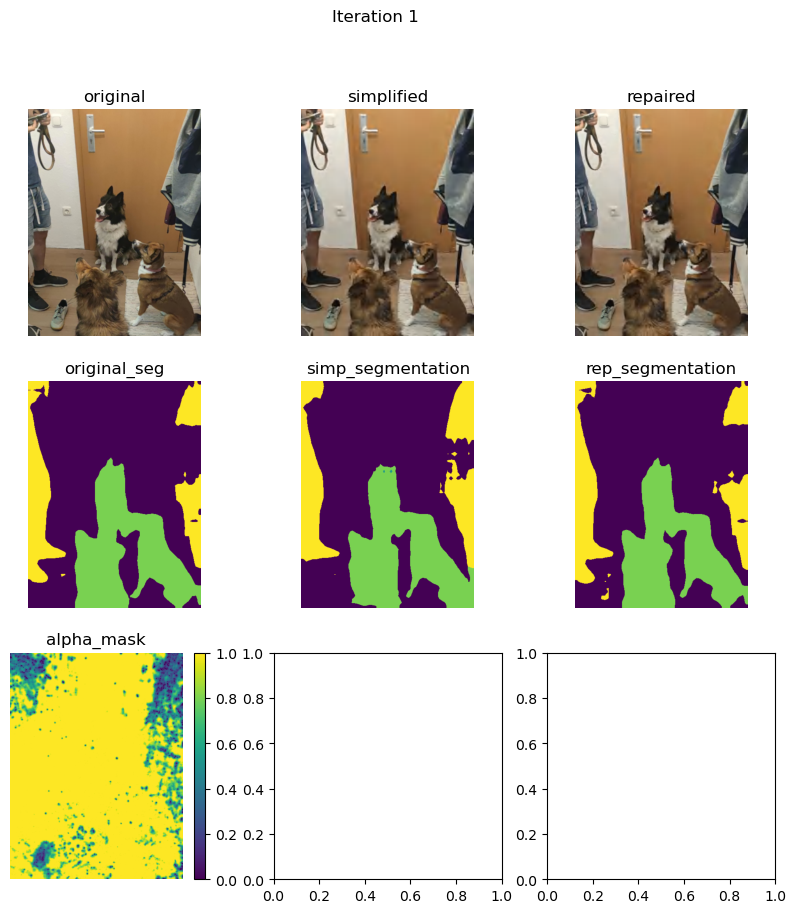

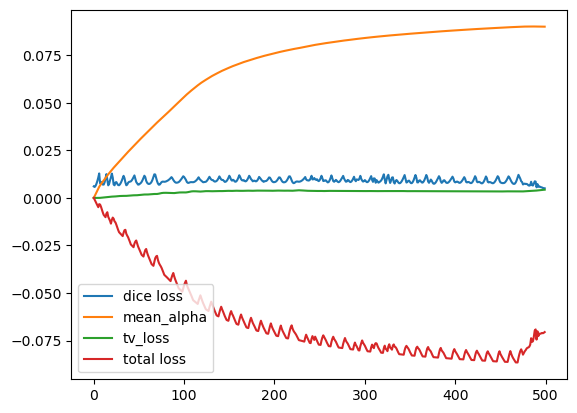

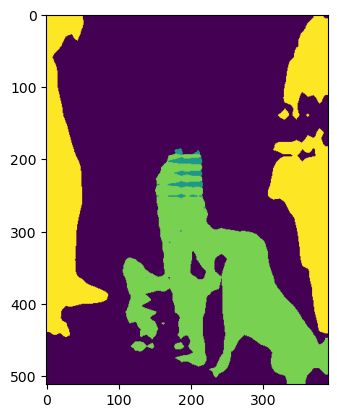

Initial dice loss for simplification 2: 0.6610
inital dice loss tensor(0.6610, device='cuda:0')
opt_it 0
decrease dice weight to 0.0
do_backprop
perform op step
loss 8.356093894690275e-05
opt_it 1
increased dice_weight to 0.2
no_improvement_counter 1
do_backprop
perform op step
loss -0.0009667392587289214
opt_it 2
increased dice_weight to 0.4
no_improvement_counter 2
do_backprop
perform op step
loss 0.00180607580114156
opt_it 3
decrease dice weight to 0.30000000000000004
do_backprop
perform op step
loss 0.0012572158593684435
opt_it 4
increased dice_weight to 0.5
no_improvement_counter 1
do_backprop
perform op step
loss 0.0004838744644075632
opt_it 5
increased dice_weight to 0.7
no_improvement_counter 2
do_backprop
perform op step
loss 0.002878033323213458
opt_it 6
decrease dice weight to 0.6
do_backprop
perform op step
loss 0.0014551952481269836
opt_it 7
decrease dice weight to 0.5
do_backprop
perform op step
loss 0.0006522517651319504
opt_it 8
decrease dice weight to 0.4
do_backprop
p

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09674771..1.0621645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13954604..1.0850232].


perform op step
loss -0.05625971406698227
opt_it 498
increased dice_weight to 3.2000000000000015
no_improvement_counter 24
do_backprop
perform op step
loss -0.056191518902778625
opt_it 499
increased dice_weight to 3.3000000000000016
no_improvement_counter 25
do_backprop
perform op step
loss -0.05649270862340927


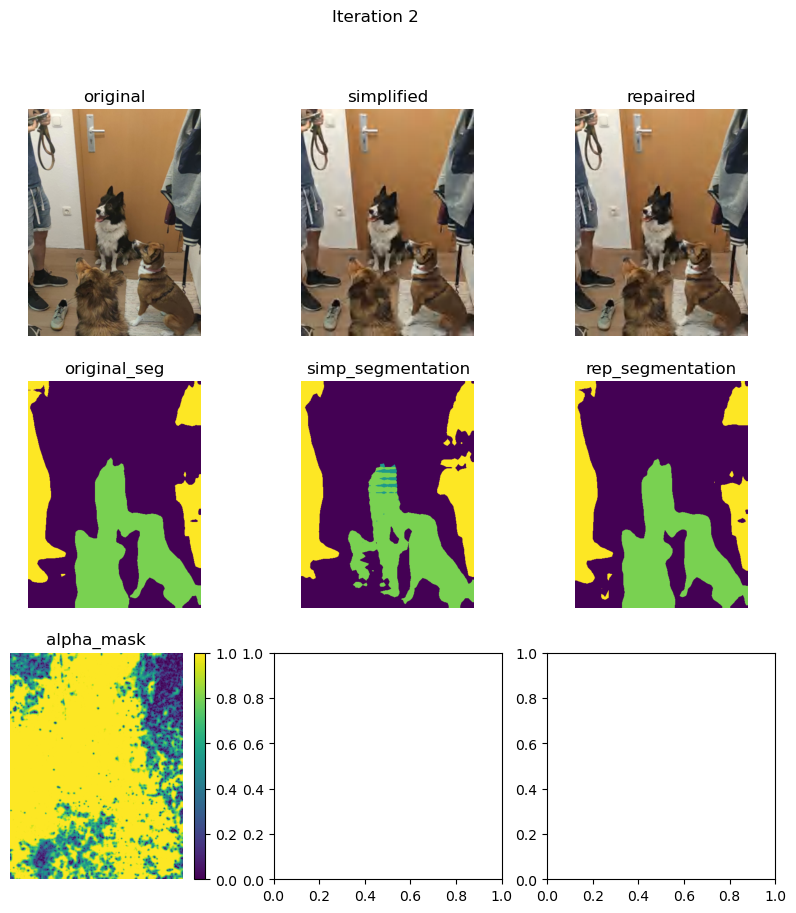

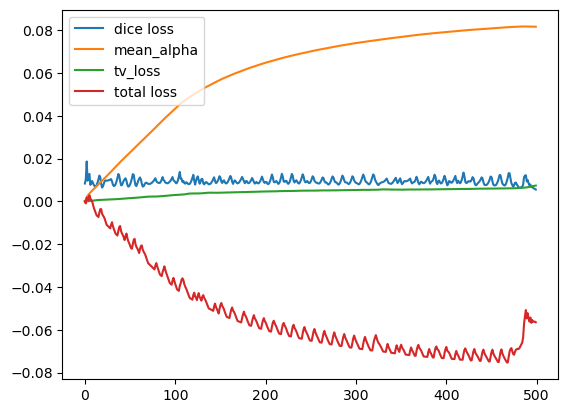

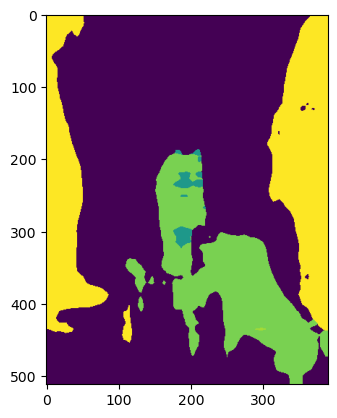

Initial dice loss for simplification 3: 0.6792
inital dice loss tensor(0.6792, device='cuda:0')
opt_it 0
decrease dice weight to 0.0
do_backprop
perform op step
loss 6.845831376267597e-05
opt_it 1
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.000978704891167581
opt_it 2
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.001955818384885788
opt_it 3
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.0029325359500944614
opt_it 4
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.003908827435225248
opt_it 5
increased dice_weight to 0.2
no_improvement_counter 1
do_backprop
perform op step
loss -0.004884678404778242
opt_it 6
increased dice_weight to 0.4
no_improvement_counter 2
do_backprop
perform op step
loss -0.002952663693577051
opt_it 7
increased dice_weight to 0.6000000000000001
no_improvement_counter 3
do_backprop
perform op step
loss -0.002355374861508608
opt_it 8
increased dice_weight to 0.8
no_improvement_counter 4
do_backprop

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13954604..1.0850232].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.28686613..1.1021639].


loss -0.042295150458812714
opt_it 437
increased dice_weight to 6.299999999999994
no_improvement_counter 50
No improvement in Dice and loss for 50 iterations, stopping.


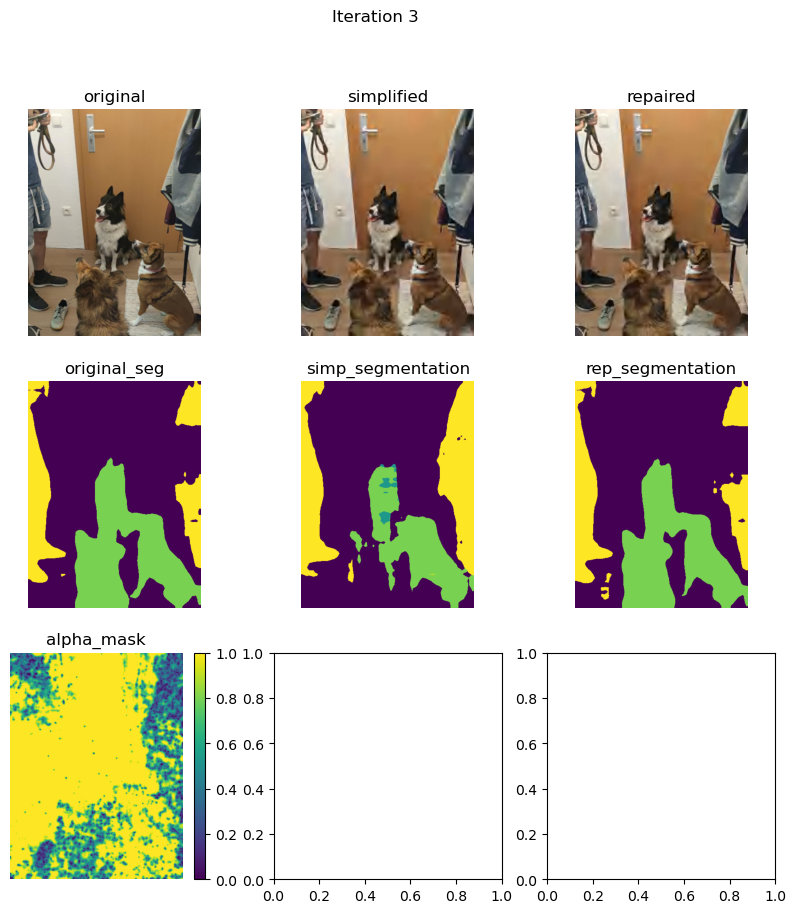

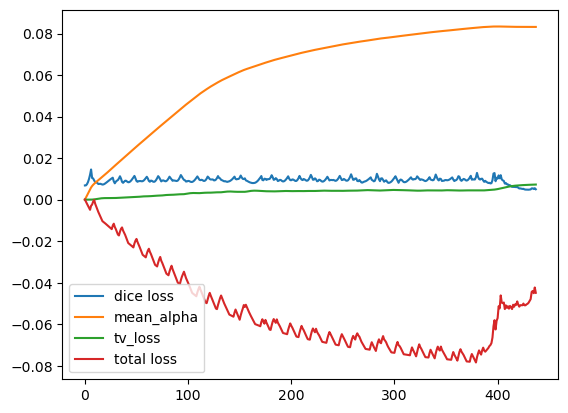

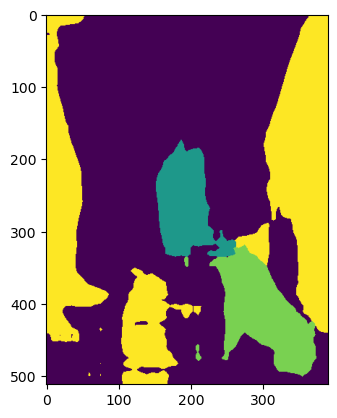

Initial dice loss for simplification 4: 0.7281
inital dice loss tensor(0.7281, device='cuda:0')
opt_it 0
decrease dice weight to 0.0
do_backprop
perform op step
loss 8.585154864704236e-05
opt_it 1
decrease dice weight to 0.0
do_backprop
perform op step
loss -0.0009764410788193345
opt_it 2
increased dice_weight to 0.2
no_improvement_counter 1
do_backprop
perform op step
loss -0.001950157224200666
opt_it 3
increased dice_weight to 0.4
no_improvement_counter 2
do_backprop
perform op step
loss -7.574912160634995e-05
opt_it 4
increased dice_weight to 0.6000000000000001
no_improvement_counter 3
do_backprop
perform op step
loss 0.002174485009163618
opt_it 5
increased dice_weight to 0.8
no_improvement_counter 4
do_backprop
perform op step
loss 0.0035405512899160385
opt_it 6
increased dice_weight to 1.0
no_improvement_counter 5
do_backprop
perform op step
loss 0.004384186118841171
opt_it 7
increased dice_weight to 1.2
no_improvement_counter 6
do_backprop
perform op step
loss 0.00575543288141489

KeyboardInterrupt: 

In [182]:
do_simplification_jpg2k(model, img, max_simp_it=10,
                        max_it_opt=500, dice_er=0.01, lambda_tv=0.8, lambda_alpha=0.1)